In [1]:
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
bias_strength = 0.1
data_set_name = "folktables_income"
method_name = "fw-mrs-temperature"
bias_type = "less_positive_class"
iteration = 0

In [3]:
load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/{method_name}/classification_results/roc_curves.json"
with open(load_path) as file:
    roc_values = json.load(file)
representative_uniform_load_path = f"../results/test_set_classification/{data_set_name}/none/1.0/uniform/classification_results/roc_curves.json"
with open(representative_uniform_load_path) as file:
    representative_roc_values = json.load(file)

biased_uniform_load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/uniform/classification_results/roc_curves.json"
with open(biased_uniform_load_path) as file:
    biased_uniform_roc_values = json.load(file)

biased_mrs_load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/mrs-forest/classification_results/roc_curves.json"
with open(biased_mrs_load_path) as file:
    biased_mrs_roc_values = json.load(file)

FileNotFoundError: [Errno 2] No such file or directory: '../results/test_set_classification/folktables_income/less_positive_class/0.1/fw-mrs-temperature/classification_results/roc_curves.json'

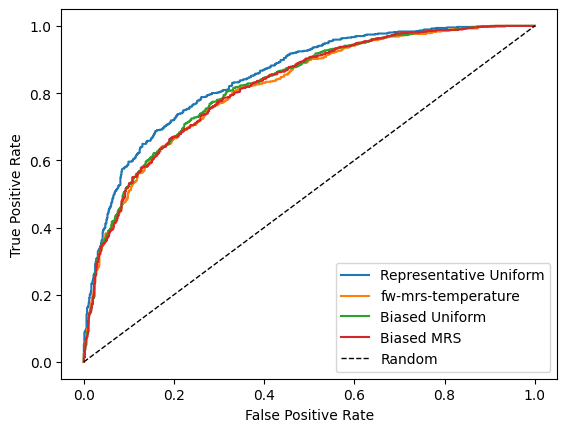

In [ ]:
one_iteration_roc = roc_values[iteration]
one_representative_roc = representative_roc_values[iteration]
one_biased_uniform_roc = biased_uniform_roc_values[iteration]
one_biased_mrs_roc = biased_mrs_roc_values[iteration]

plt.plot(one_representative_roc[0], one_representative_roc[1], label="Representative Uniform")
plt.plot(one_iteration_roc[0], one_iteration_roc[1], label=method_name)
plt.plot(one_biased_uniform_roc[0], one_biased_uniform_roc[1], label="Biased Uniform")
plt.plot(one_biased_mrs_roc[0], one_biased_mrs_roc[1], label="Biased MRS")
plt.plot(
        [0, 1], [0, 1], color="black", linestyle="--", label="Random", linewidth=1
    )

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

In [4]:
load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/{method_name}/classification_results/feature_importance.json"
with open(load_path) as file:
    feature_importance = json.load(file)
representative_uniform_load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/1.0/uniform/classification_results/feature_importance.json"
with open(representative_uniform_load_path) as file:
    representative_feature_importance = json.load(file)

biased_uniform_load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/uniform/classification_results/feature_importance.json"
with open(biased_uniform_load_path) as file:
    biased_uniform_feature_importance = json.load(file)

biased_mrs_load_path = f"../results/test_set_classification/{data_set_name}/{bias_type}/{bias_strength}/mrs-forest/classification_results/feature_importance.json"
with open(biased_uniform_load_path) as file:
    biased_mrs_feature_importance = json.load(file)

FileNotFoundError: [Errno 2] No such file or directory: '../results/test_set_classification/folktables_income/less_positive_class/0.1/fw-mrs-temperature/classification_results/feature_importance.json'

In [5]:
import pandas as pd
sns.set_theme(rc={'figure.figsize':(20,6)})
one_iteration_feature_importance = feature_importance[iteration] / np.sum(feature_importance[iteration])
one_representative_feature_importance = representative_feature_importance[iteration] / np.sum(representative_feature_importance[iteration])
one_biased_uniform_feature_importance = biased_uniform_feature_importance[iteration] / np.sum(biased_uniform_feature_importance[iteration])
one_biased_mrs_feature_importance = biased_mrs_feature_importance[iteration] / np.sum(biased_mrs_feature_importance[iteration])

feature_importances = pd.DataFrame(
    [
        {"Method": method_name, "mean_values": np.array(one_iteration_feature_importance)},
        {"Method": "Representative Uniform", "mean_values": np.array(one_representative_feature_importance)},
        {"Method": "Biased Uniform", "mean_values": np.array(one_biased_uniform_feature_importance)},
        {"Method": "Biased MRS", "mean_values": np.array(one_biased_mrs_feature_importance)},
    ]
        )
feature_importances = feature_importances.explode(["mean_values"])
feature_importances['subgroup'] = feature_importances.groupby('Method').cumcount()+1
ax = sns.barplot(feature_importances, x="subgroup" , y="mean_values", hue="Method", width=1)

NameError: name 'feature_importance' is not defined

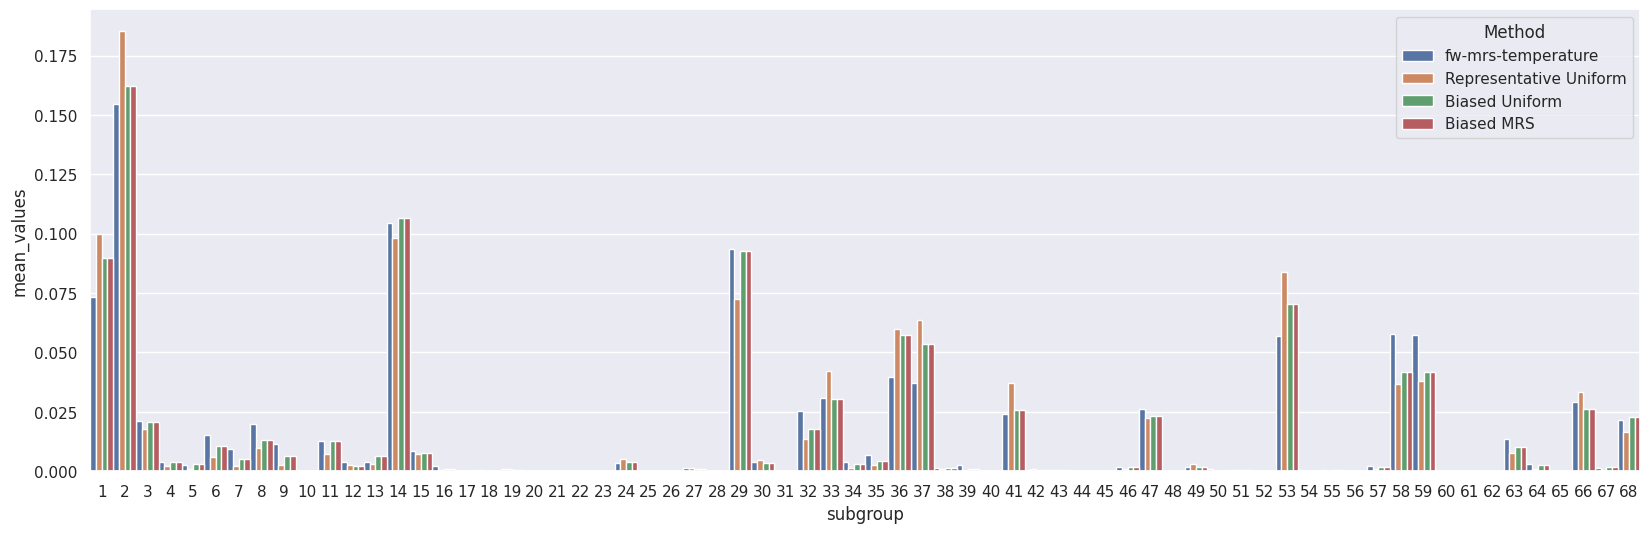

In [7]:
sns.set_theme(rc={'figure.figsize':(20,6)})
one_iteration_feature_importance = np.mean(feature_importance, axis=0)
one_iteration_feature_importance /= np.sum(one_iteration_feature_importance)

one_representative_feature_importance = np.mean(representative_feature_importance, axis=0)
one_representative_feature_importance /=  np.sum(one_representative_feature_importance)

one_biased_uniform_feature_importance = np.mean(biased_uniform_feature_importance, axis=0)
one_biased_uniform_feature_importance /= np.sum(one_biased_uniform_feature_importance)

one_biased_mrs_feature_importance = np.mean(biased_mrs_feature_importance, axis=0)
one_biased_mrs_feature_importance /= np.sum(one_biased_mrs_feature_importance)

feature_importances = pd.DataFrame([{"Method": method_name, "mean_values": np.array(one_iteration_feature_importance)},
                        {"Method": "Representative Uniform", "mean_values": np.array(one_representative_feature_importance)},
                       {"Method": "Biased Uniform", "mean_values": np.array(one_biased_uniform_feature_importance)},
                       {"Method": "Biased MRS", "mean_values": np.array(one_biased_mrs_feature_importance)},
                       ]
                       )
feature_importances = feature_importances.explode(["mean_values"])
feature_importances['subgroup'] = feature_importances.groupby('Method').cumcount()+1
ax = sns.barplot(feature_importances, x="subgroup" , y="mean_values", hue="Method", width=1)